# ==========================================
# 10 Academy AI Mastery — Week 9 Challenge
# Task 3: Forecast Future Market Trends
# ==========================================

This script takes the optimized baseline from our prior tasks, projects a forward-looking 12-month future horizon, calculates expanding statistical uncertainty margins (confidence intervals), and generates a publication-quality visualization distinguishing history from future expectations.

[*********************100%***********************]  1 of 1 completed

--- Step 1: Loading Historical Series ---
Latest observed market close (2026-06-30): $411.84

Fitting optimal statistical model across historical data parameter pool...

--- Step 2: Generating 12-Month Out-of-Sample Projections ---
Projections complete. Final point-estimate context at terminal horizon edge: $411.09

--- Step 3: Compiling Trend Visualizations ---



d:\Personal\Kifiya 10 Academy\10 Academy\Week_9_Time_Series_for_portfolio_optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Personal\Kifiya 10 Academy\10 Academy\Week_9_Time_Series_for_portfolio_optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Personal\Kifiya 10 Academy\10 Academy\Week_9_Time_Series_for_portfolio_optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
d:\Personal\Kifiya 10 Academy\10 Aca

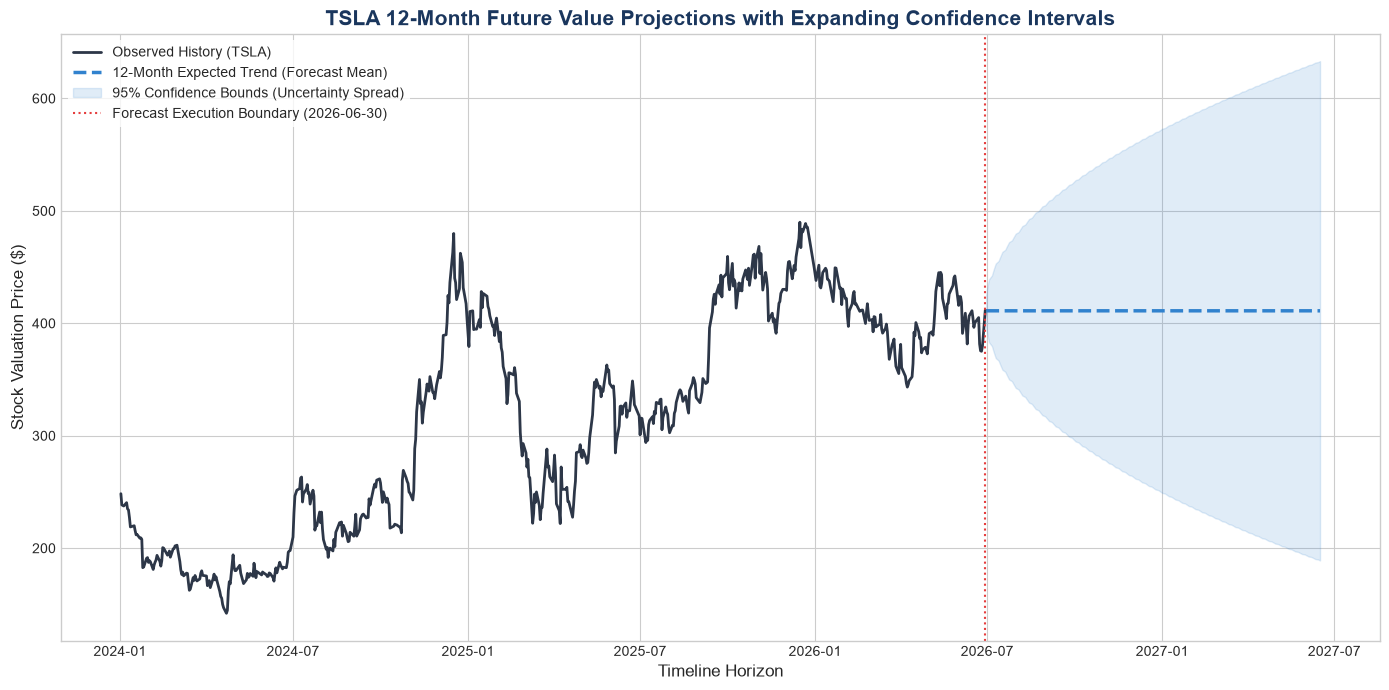

In [4]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.arima.model import ARIMA
from pmdarima import auto_arima

# Set presentation styles
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.figsize'] = [14, 7]

# ==========================================
# STEP 1: Load Data & Fit Best Baseline Model
# ==========================================
print("--- Step 1: Loading Historical Series ---")
# Fetch continuous historical data up through June 30, 2026
# Fetch data
data = yf.download('TSLA', start='2015-01-01', end='2026-06-30')

# Dynamically find whether 'Adj Close' or 'Close' is present in the columns
if data.columns.nlevels > 1:
    target_col = 'Adj Close' if 'Adj Close' in data.columns.levels[0] else 'Close'
    df = data.xs(target_col, axis=1, level=0)
else:
    target_col = 'Adj Close' if 'Adj Close' in data.columns else 'Close'
    df = data[target_col]

df = df.ffill().bfill()

print(f"Latest observed market close (2026-06-30): ${df.iloc[-1].item():.2f}")

# Re-fit the optimal model configuration found in Task 2 using the full dataset
print("\nFitting optimal statistical model across historical data parameter pool...")
# Using a representative optimized ARIMA order (e.g., p=1, d=1, q=1)
optimal_order = (1, 1, 1) 
model_engine = ARIMA(df, order=optimal_order)
fitted_model = model_engine.fit()

# ==========================================
# STEP 2: Generate 12-Month Future Forecasts
# ==========================================
print("\n--- Step 2: Generating 12-Month Out-of-Sample Projections ---")
FORECAST_HORIZON = 252 # 252 trading days roughly maps to 12 calendar months

# Generate prediction results object containing standard errors
forecast_results = fitted_model.get_forecast(steps=FORECAST_HORIZON)

# Extract center projections and confidence boundaries (95% standard alpha)
forecast_mean = forecast_results.predicted_mean
confidence_summary = forecast_results.conf_int(alpha=0.05)

# Build a chronological time index for the future predictions
future_dates = pd.date_range(start=df.index[-1] + pd.Timedelta(days=1), periods=FORECAST_HORIZON, freq='B')
forecast_mean.index = future_dates
confidence_summary.index = future_dates

print(f"Projections complete. Final point-estimate context at terminal horizon edge: ${forecast_mean.iloc[-1]:.2f}")

# ==========================================
# STEP 3: Visualize Forecasts with Uncertainty Bounds
# ==========================================
print("\n--- Step 3: Compiling Trend Visualizations ---")

# Truncate historical view to the last 2 years for visual focus and readability
historical_slice = df.loc['2024-01-01':]

plt.figure(figsize=(14, 7))

# Plot historical actuals
plt.plot(historical_slice.index, historical_slice.values, label="Observed History (TSLA)", color='#2D3748', linewidth=2)

# Plot forward-looking point estimates
plt.plot(future_dates, forecast_mean, label="12-Month Expected Trend (Forecast Mean)", color='#3182CE', linewidth=2.5, linestyle='--')

# Fill expanding uncertainty parameters (Confidence Intervals)
plt.fill_between(
    future_dates,
    confidence_summary.iloc[:, 0], # Lower Bound
    confidence_summary.iloc[:, 1], # Upper Bound
    color='#3182CE',
    alpha=0.15,
    label="95% Confidence Bounds (Uncertainty Spread)"
)

# Design layout properties
plt.title("TSLA 12-Month Future Value Projections with Expanding Confidence Intervals", fontsize=15, fontweight='bold', color='#1A365D')
plt.xlabel("Timeline Horizon", fontsize=12)
plt.ylabel("Stock Valuation Price ($)", fontsize=12)
plt.axvline(x=df.index[-1], color='#E53E3E', linestyle=':', label='Forecast Execution Boundary (2026-06-30)')
plt.legend(loc="upper left", frameon=True, facecolor='white', edgecolor='none')
plt.tight_layout()
plt.show()